## Import Libraries

In [1]:
!pip install qiskit --upgrade
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 67.4 MB/s eta 0:00:00


In [2]:

import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Kraus, SuperOp
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import Statevector,DensityMatrix,state_fidelity,partial_trace, Operator
from matplotlib import pyplot as plt
from functools import reduce
from scipy.linalg import expm
import pandas as pd
from qiskit_aer import AerSimulator
from qiskit import transpile

#from qiskit import Aer, execute, transpile


# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)

Hamiltonian:

$H=-h(X_1+X_2)-J Z_1 Z_2$

Trotter formula:

$e^{-iH t}=(e^{i h X_1 \Delta t}e^{i h X_2 \Delta t}e^{i J Z_1 Z_2 \Delta t})^{N_{\text{Trot}}},$

where $\Delta t=t/N_{\text{Trot}}$.

## Pure SWAPNET for general d - Simple Initial State

### Set Base Funcs for base state with noise

In [3]:
def circuit_with_noise_at_end(qc, d, epsilon):
    # Define the depolarizing error
    depolarizing = depolarizing_error(epsilon, d)

    # Apply the depolarizing noise to each d-sized register
    qc.append(depolarizing, range(d, 2*d))  # Second register
    qc.append(depolarizing, range(2*d, 3*d))  # Third register
    qc.append(depolarizing, range(3*d, 4*d))  # Fourth register

    return qc



def getExactState(n_qubits):
    # Create an initial state (|00...0>)
    initial_state = np.zeros(2**n_qubits)
    #print('Initial array:', initial_state)
    initial_state[0] = 1
    pure_state = DensityMatrix(initial_state)

    return pure_state

# Input state without purification, used for benchmarking

def getInputRho(epsilon, d):

    # Create a Quantum Circuit acting on a quantum register of d qubits

    depolarizing = depolarizing_error(epsilon, d)
    qc = QuantumCircuit(d)
    qc.append(depolarizing, [0, d-1])
    state = DensityMatrix(qc)

    return state


### Set SWAPNET

In [4]:
import time
from itertools import product

def getPurifiedRhoWithSWAP1213GHZ_general(epsilon,n,flag,d,debug=False, debug_time=False):
    start_time = time.time()
    # Create a Quantum Circuit acting on 4 quantum register of d qubits
    qc = QuantumCircuit(4*d)
    # Initialize the 3 registers with a noisy state
    qc=circuit_with_noise_at_end(qc, d, epsilon)


    list_rho_odd=[]
    list_rho_even=[]
    list_p00or11_odd=[]
    list_p00or11_even=[]
    list_p01or10_odd=[]
    list_p01or10_even=[]

    qc_odd = QuantumCircuit(4*d)
    for k in range(d):
      qc_odd.reset(k) #q0 =|0000...>

    # Apply creating the GHZ state for general d dimensions
    qc_odd.h(0) #q0_firstqbit = |0>+|1>/sqrt2
    for k in range(d-1):
      qc_odd.cx(0,1+k) #q0 = |0000...> + |1111...>/sqrt2

    # Apply the first CSWAP gate controlled by q0, targeting q1 and q2
    for k in range(d):
      qc_odd.cswap(0+k, d+k, 2*d+k) #|+> x SYM12 + |-> x AntiSYM12 /norm

    # Apply the second Hadamard gate to q0
    for k in range(d):
      qc_odd.h(k) #|0> x SYM13 + |1> x AntiSYM13 /norm





    qc_even = QuantumCircuit(4*d)
    for k in range(d):
      qc_even.reset(k) #q0 =|0000...>
    qc_even.h(0)#q0_firstqbit = |0>+|1>/sqrt2
    for k in range(d-1):
      qc_even.cx(0,1+k) #q0 = |0000...> + |1111...>/sqrt2

    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    for k in range(d):
      qc_even.cswap(0+k, d+k, 3*d+k) #|+> x SYM13 + |-> x AntiSYM13 /norm

    # Apply the second Hadamard gate to the first and second qubit
    for k in range(d):
      qc_even.h(k)






    # Apply the Hadamard gate to q0
    qc.h(0)#q0_firstqbit = |0>+|1>/sqrt2
    for k in range(d-1):
      qc.cx(0,1+k)#q0 = |0000...> + |1111...>/sqrt2


    # Apply the first CSWAP gate controlled by q0, targeting q1 and q2
    for k in range(d):
      qc.cswap(0+k, k+d, k+2*d)#|+> x SYM12 + |-> x AntiSYM12 /norm

    # Apply the second Hadamard gate to q0
    for k in range(d):
      qc.h(k) #|0> x SYM12 + |1> x AntiSYM12 /norm

    state = DensityMatrix(qc)
    if debug:
      print('State created:',state,'\n\n')
      print('Trace of state:', np.trace(state),'\n\n')

    state = state/np.trace(state)
    # Define the |0><0| projection matrix for a single qubit
    projection_start = time.time()
    P0 = np.array([[1, 0],
                   [0, 0]])
    P1 = np.array([[0, 0],
                   [0, 1]])

    # List of all possible results that we can get from measuring the register q0. If we have d=2 for example, the possible results are [0,0], [1,0], [0,1], [1,1]
    I = np.eye(2)
    possible_projections = list(product([0, 1], repeat=d))
    if debug:
      print('Projections of q0:',possible_projections)

    def extract_projected_state(rho, d, projection):
        """
        Extracts the projected density matrix for a given measurement outcome without explicit projection matrices.

        Parameters:
        - rho: The full density matrix (Qiskit DensityMatrix object)
        - d: Number of qubits in the measured register
        - projection: A binary tuple indicating the measurement outcome (e.g., (0,1,0) for q0)

        Returns:
        - projected_rho: The full-sized projected density matrix
        - prob: Probability of obtaining this measurement outcome
        """
        rho_array = rho.data  # Convert Qiskit DensityMatrix to NumPy array
        num_qubits = int(np.log2(rho.dim))  # Get number of qubits from matrix dimension

        # Convert projection outcome into basis indices (full dimension)
        basis_indices = [i for i in range(2**num_qubits) if all(((i >> q) & 1) == bit for q, bit in enumerate(projection))]

        # Create a zero matrix of the same size as rho
        projected_rho = np.zeros_like(rho_array)

        # Copy only the elements corresponding to the projection outcome
        for i in basis_indices:
            for j in basis_indices:
                projected_rho[i, j] = rho_array[i, j]

        # Compute probability (trace of the projected part)
        prob = np.trace(projected_rho).real

        return DensityMatrix(projected_rho), prob
    def do_all_projections(state):
      p0 = 0
      p1 = 0
      rho0 = np.zeros_like(state.data)  # Initialize rho0 as a zero matrix
      rho1 = np.zeros_like(state.data)  # Initialize rho1 as a zero matrix

      for projection in possible_projections:
          # parity = sum(projection) % 2 #If there is an even amount of z=1 inside q0, it is a p=1 measurement, if there is an odd amount, it's a z=0 measurements
          # projection_operator = Operator(I)
          # for i in range(3*d-1):
          #   projection_operator = projection_operator.tensor(Operator(I)) # Leave q1,q2, and q3 unchanged
          # for i in range(d):
          #   if projection[i]==0: #
          #     projection_operator = projection_operator.tensor(Operator(P0)) # Project q0 to the result
          #   else:
          #     projection_operator = projection_operator.tensor(Operator(P1))
          # projected_rho = projection_operator @ state @ projection_operator.adjoint()
          # prob = np.trace(projected_rho.data).real
          # projected_rho_new, prob_new = extract_projected_state(state, d, projection)
          # projected_rho, prob = extract_projected_state(state, d, projection)
          # print(f'prob = {prob}, prob_new = {prob_new}')
          #print(f'prob-prob_new={prob-prob_new}')
          #print(f'Difference in rhos={(projected_rho-projected_rho_new).data.real.nonzero()}')

          projected_rho, prob = extract_projected_state(state, d, projection)
          parity = sum(projection) % 2

          if parity == 0:
              p0 += prob
              rho0 += projected_rho.data  # Add as NumPy array
          else:
              p1 += prob
              rho1 += projected_rho.data

      # Normalize probabilities
      total_prob = p0 + p1
      if total_prob > 0:
          p0 /= total_prob
          p1 /= total_prob

      # Avoid division by zero
      if p0 > 0:
          rho0 /= p0
      if p1 > 0:
          rho1 /= p1

      # Convert back to DensityMatrix objects
      return p0, DensityMatrix(rho0), p1, DensityMatrix(rho1)


    # Calculate projections and probabilities for each possible result
    p0_odd,rho0_odd,p1_odd,rho1_odd=do_all_projections(state)
    projection_end = time.time()
    projection_time = projection_end - projection_start

    list_p00or11_odd.append(p0_odd)
    list_p01or10_odd.append(p1_odd)
    list_rho_odd.append(partial_trace(DensityMatrix((rho1_odd)), [i for i in range(3*d)]))
    if debug:
      print('Probabilities on 1st it:',p0_odd,p1_odd)

    # update the state
    state=DensityMatrix((rho0_odd))


    #EVEN SWAP ---------------------------------------------------------------------------------------------
    apply_circuit_start = time.time()
    state = state.evolve(qc_even)
    apply_circuit_end = time.time()
    apply_circuit_time = apply_circuit_end - apply_circuit_start

    p0_even,rho0_even,p1_even,rho1_even=do_all_projections(state)
    list_p00or11_even.append(p0_even)
    list_p01or10_even.append(p1_even)
    list_rho_even.append(partial_trace(DensityMatrix((rho1_even)), ([i for i in range(2*d)]+[i for i in range(3*d,4*d)])))
    if debug:
      print('Probabilities on 2nd it:',p0_even,p1_even)
    # Trace out qubits q0, q1, q2, q3, q6, and q7


    # update the state
    state=DensityMatrix((rho0_even)/(p0_even))


    for i in range(n-1):
            # Block A

            state=state.evolve(qc_odd)
            p0_odd,rho0_odd,p1_odd,rho1_odd=do_all_projections(state)
            list_p00or11_odd.append(p0_odd)
            list_p01or10_odd.append(p1_odd)
            list_rho_odd.append(partial_trace(DensityMatrix((rho1_odd)), [i for i in range(3*d)]))
            # update the state
            state=DensityMatrix((rho0_odd))

            # Block B
            state=state.evolve(qc_even)

            p0_even,rho0_even,p1_even,rho1_even=do_all_projections(state)
            list_p00or11_even.append(p0_even)
            list_p01or10_even.append(p1_even)

            list_rho_even.append(partial_trace(DensityMatrix((rho1_even)), ([i for i in range(2*d)]+[i for i in range(3*d,4*d)])))
            state=DensityMatrix((rho0_even))

    final_matrix_start = time.time()

    purified_rho=list_p01or10_odd[0]*list_rho_odd[0]
    purified_rho=purified_rho+list_p00or11_odd[0]*list_p01or10_even[0]*list_rho_even[0]

    for j in range(n-1):
        #print(j)
        product_list_p00or11_odd=reduce(lambda x, y: x * y, list_p00or11_odd[:j+1])
        product_list_p00or11_even=reduce(lambda x, y: x * y, list_p00or11_even[:j+1])
        product_list_p00or11=product_list_p00or11_odd*product_list_p00or11_even

        purified_rho=purified_rho+product_list_p00or11*list_p01or10_odd[j+1]*list_rho_odd[j+1]
        purified_rho=purified_rho+product_list_p00or11*list_p00or11_odd[j+1]*list_p01or10_even[j+1]*list_rho_even[j+1]

    product_list_p00or11_odd=reduce(lambda x, y: x * y, list_p00or11_odd[:n])
    product_list_p00or11_even=reduce(lambda x, y: x * y, list_p00or11_even[:n])
    product_list_p00or11=product_list_p00or11_odd*product_list_p00or11_even

    if flag > 0:
        purified_rho=partial_trace(state, ([i for i in range(d)]+[i for i in range(2*d,4*d)])) #[q0,q2,q3]
    else:
        purified_rho=purified_rho+product_list_p00or11*partial_trace(state,[i for i in range(3*d)] ) # [q0,q1,q2]
    final_matrix_end = time.time()
    final_matrix_time = final_matrix_end - final_matrix_start

    total_time = time.time() - start_time
    if debug_time:
        print(f"Total execution time: {total_time:.3f} seconds")
        print(f"Projection step time: {projection_time:.3f} seconds ({100 * projection_time/total_time:.2f}%)")
        print(f"Applying qc_even/qc_odd time: {apply_circuit_time:.3f} seconds ({100 * apply_circuit_time/total_time:.2f}%)")
        print(f"Final density matrix computation time: {final_matrix_time:.3f} seconds ({100 * final_matrix_time/total_time:.2f}%)")
        print('\n\n\n')
    return DensityMatrix(purified_rho)/np.trace(DensityMatrix(purified_rho))

### Test SWAPNET

In [5]:
#Simultation code
list_of_epsilon=[i * 0.05 for i in range(6)]
list_of_purified_fidelity_flag0=[]
list_of_purified_fidelity_flag0_n1=[]
list_of_purified_fidelity_flag0_n2=[]
list_of_purified_fidelity_theory=[]
list_of_fidelity=[]


d=2
pure_state =getExactState(d)
#print('Initial Pure state:', pure_state)
for i in list_of_epsilon:
    # noisy_state = getInputRho(i,d)
    # QPA_state = getPurifiedRhoWithSWAP1213GHZ_general(i,1,0,d)
    # print('Noise state:', noisy_state)
    # print('\n\n','QPA State:', QPA_state)
    list_of_purified_fidelity_flag0_n1.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ_general(i,1,0,d,debug_time=True), pure_state))
    # list_of_purified_fidelity_flag0_n2.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ_general(i,2,N,0,d), pure_state))
    # list_of_purified_fidelity_flag0.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ_general(i,10,N,0,d), pure_state))
    list_of_purified_fidelity_theory.append(1/8*(-2+i)*(1+i)*(-4+3*i))
    list_of_fidelity.append(state_fidelity(getInputRho(i,d), pure_state))

Total execution time: 0.859 seconds
Projection step time: 0.034 seconds (3.97%)
Applying qc_even/qc_odd time: 0.355 seconds (41.34%)
Final density matrix computation time: 0.006 seconds (0.67%)




Total execution time: 1.042 seconds
Projection step time: 0.036 seconds (3.43%)
Applying qc_even/qc_odd time: 0.274 seconds (26.25%)
Final density matrix computation time: 0.003 seconds (0.28%)




Total execution time: 0.596 seconds
Projection step time: 0.020 seconds (3.38%)
Applying qc_even/qc_odd time: 0.201 seconds (33.63%)
Final density matrix computation time: 0.002 seconds (0.35%)




Total execution time: 0.481 seconds
Projection step time: 0.017 seconds (3.46%)
Applying qc_even/qc_odd time: 0.185 seconds (38.47%)
Final density matrix computation time: 0.002 seconds (0.45%)




Total execution time: 0.621 seconds
Projection step time: 0.047 seconds (7.62%)
Applying qc_even/qc_odd time: 0.233 seconds (37.52%)
Final density matrix computation time: 0.002 seconds (0.26%)




Total exec

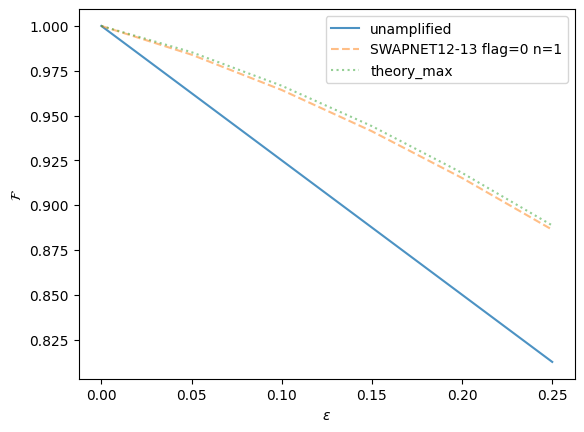

In [6]:
plt.plot(list_of_epsilon,list_of_fidelity,label='unamplified', alpha=0.8)
plt.plot(list_of_epsilon,list_of_purified_fidelity_flag0_n1,label='SWAPNET12-13 flag=0 n='+str(1), alpha=0.5, linestyle='dashed')
# plt.plot(list_of_epsilon,list_of_purified_fidelity_flag0_n2,label='SWAPNET12-13 flag=0 n='+str(2), alpha=0.5, linestyle='dashed')
plt.plot(list_of_epsilon,list_of_purified_fidelity_theory,label='theory_max', alpha=0.5, linestyle='dotted')

plt.xlabel("$\\epsilon$")
plt.ylabel("$\\mathcal{F}$")
plt.legend()